In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_raw = pd.read_excel('SDC.xlsx', header=None)
data_raw

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,Ventas,NaN,12,7,8,13,6,21,17,17,...,38,30,41,41,35,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Indicador,"Enero, 24","Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24","Julio, 24","Agosto, 24","Septiembre, 24",...,"Marzo, 26","Abril, 26","Mayo,26","Junio, 26","Julio,26",Total 2024,Total 2025,Total 2026,NaN,NaN
3,Generadas,5,6,11,23,26,43,55,36,56,...,85,74,95,82,32,519,1178,450,1697.0,0.392457
4,Aprobadas,1,2,7,14,8,13,30,19,26,...,41,42,44,35,12,215,451,201,666.0,0.509009
5,Condicionadas,0,0,1,0,4,0,3,0,1,...,14,16,17,10,9,100,287,102,387.0,NaN
6,Rechazadas,4,4,4,9,14,22,17,13,13,...,30,16,30,33,9,163,392,137,555.0,NaN
7,Formalizadas,1,1,5,11,3,6,17,9,7,...,18,16,19,13,4,105,234,91,339.0,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,% de Aprobación,0.2,0.333333,0.636364,0.608696,0.307692,0.302326,0.545455,0.527778,0.464286,...,0.482353,0.567568,0.463158,0.426829,0.375,0.414258,0.382852,0.446667,NaN,NaN


In [3]:
meses = data_raw.iloc[2, 1:20].tolist()

indicadores = ['Generadas', 'Aprobadas', 'Condicionadas', 'Rechazadas', 'Formalizadas']
datos_indicadores = {}
for fila, nombre in zip(range(3, 8), indicadores):
    datos_indicadores[nombre] = data_raw.iloc[fila, 1:20].tolist()

datos_indicadores['% de Aprobacion'] = data_raw.iloc[9, 1:20].tolist()
datos_indicadores['% de Formalizacion'] = data_raw.iloc[10, 1:20].tolist()

data = pd.DataFrame(datos_indicadores, index=meses)
data.index.name = 'Mes'
data

,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobacion,% de Formalizacion
Mes,,,,,,,
"Enero, 24",5,1,0,4,1,0.200000,1.000000
"Febrero, 24",6,2,0,4,1,0.333333,0.500000
"Marzo, 24",11,7,1,4,5,0.636364,0.714286
"Abril, 24",23,14,0,9,11,0.608696,0.785714
"Mayo, 24",26,8,4,14,3,0.307692,0.375000
"Junio, 24",43,13,0,22,6,0.302326,0.461538
"Julio, 24",55,30,3,17,17,0.545455,0.566667
"Agosto, 24",36,19,0,13,9,0.527778,0.473684
"Septiembre, 24",56,26,1,13,7,0.464286,0.269231


In [4]:
data.info()

<class 'pandas.DataFrame'>
Index: 19 entries, Enero, 24 to Julio, 25
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Generadas           19 non-null     int64  
 1   Aprobadas           19 non-null     int64  
 2   Condicionadas       19 non-null     int64  
 3   Rechazadas          19 non-null     int64  
 4   Formalizadas        19 non-null     int64  
 5   % de Aprobacion     19 non-null     float64
 6   % de Formalizacion  19 non-null     float64
dtypes: float64(2), int64(5)
memory usage: 1.2+ KB


In [5]:
valores_nulos = data.isnull().sum()
valores_nulos

Generadas             0
Aprobadas             0
Condicionadas         0
Rechazadas            0
Formalizadas          0
% de Aprobacion       0
% de Formalizacion    0
dtype: int64

<Figure size 1500x800 with 0 Axes>

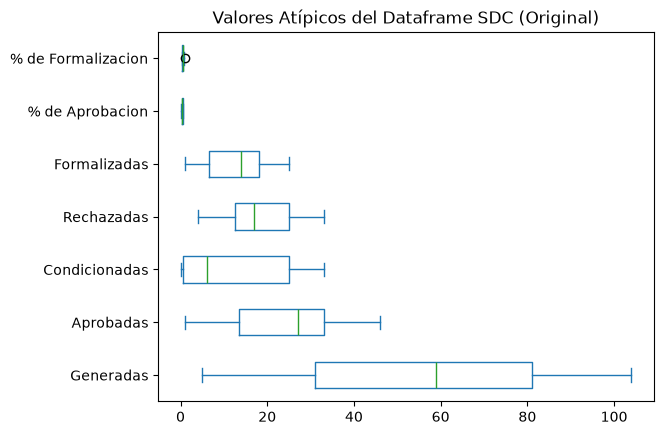

In [6]:
fig = plt.figure(figsize=(15, 8))
data.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe SDC (Original)")
plt.show()

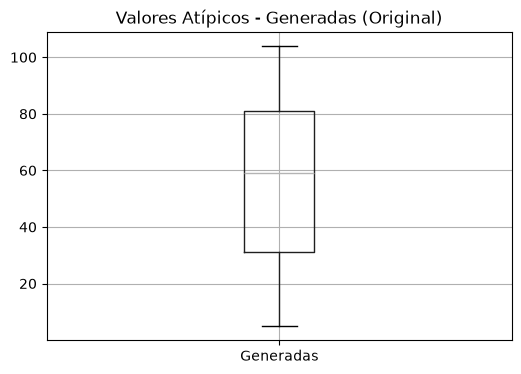

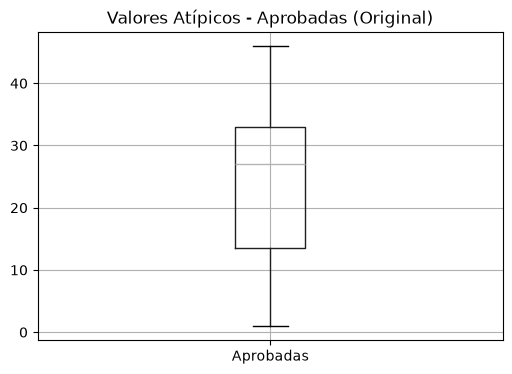

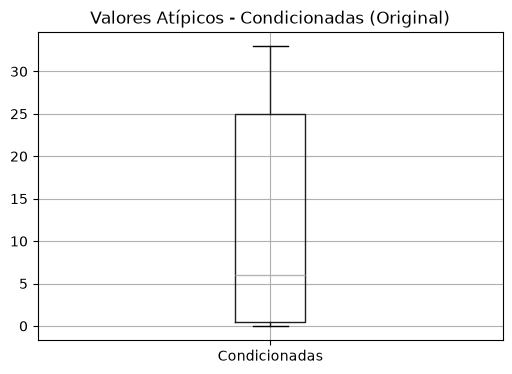

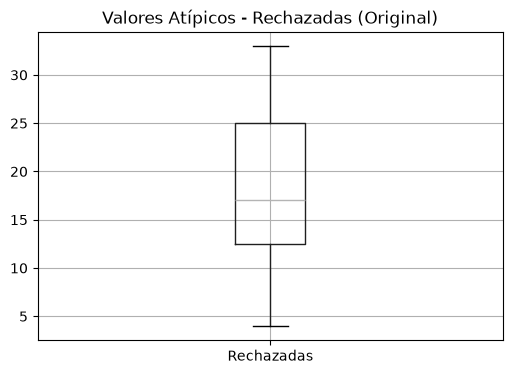

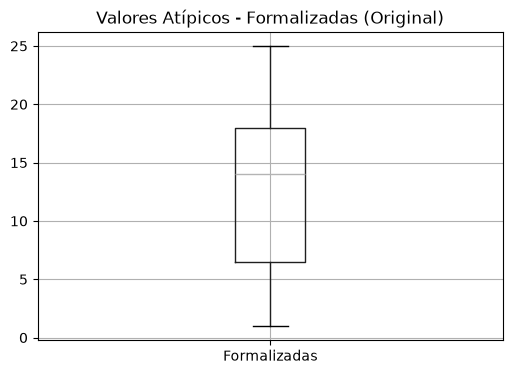

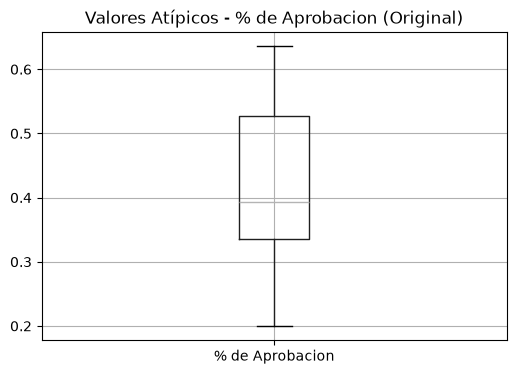

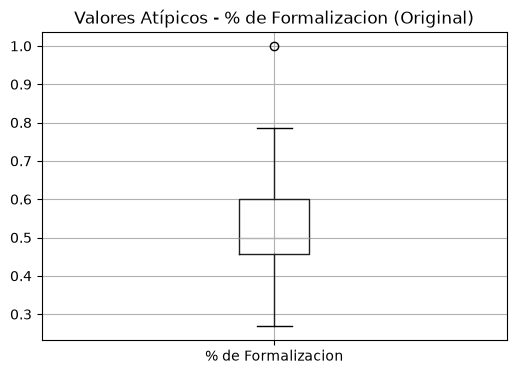

In [7]:
for columna in data.columns:
    plt.figure(figsize=(6, 4))
    data.boxplot(column=columna)
    plt.title(f"Valores Atípicos - {columna} (Original)")
    plt.show()

In [8]:
y = data

percentile25 = y.quantile(0.25) #Q1
percentile75 = y.quantile(0.75) #Q3
iqr = percentile75 - percentile25

Limite_Superior_iqr = percentile75 + 1.5*iqr
Limite_Inferior_iqr = percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido Generadas             156.000000
Aprobadas              62.250000
Condicionadas          61.750000
Rechazadas             43.750000
Formalizadas           35.250000
% de Aprobacion         0.814900
% de Formalizacion      0.815136
dtype: float64
Limite inferior permitido Generadas            -44.000000
Aprobadas            -15.750000
Condicionadas        -36.250000
Rechazadas            -6.250000
Formalizadas         -10.750000
% de Aprobacion        0.047292
% de Formalizacion     0.241439
dtype: float64


In [9]:
data3_iqr = data[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data3_iqr

,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobacion,% de Formalizacion
Mes,,,,,,,
"Enero, 24",5,1,0,4,1,0.200000,NaN
"Febrero, 24",6,2,0,4,1,0.333333,0.500000
"Marzo, 24",11,7,1,4,5,0.636364,0.714286
"Abril, 24",23,14,0,9,11,0.608696,0.785714
"Mayo, 24",26,8,4,14,3,0.307692,0.375000
"Junio, 24",43,13,0,22,6,0.302326,0.461538
"Julio, 24",55,30,3,17,17,0.545455,0.566667
"Agosto, 24",36,19,0,13,9,0.527778,0.473684
"Septiembre, 24",56,26,1,13,7,0.464286,0.269231


In [10]:
valores_nulos = data3_iqr.isnull().sum()
valores_nulos

Generadas             0
Aprobadas             0
Condicionadas         0
Rechazadas            0
Formalizadas          0
% de Aprobacion       0
% de Formalizacion    1
dtype: int64

In [11]:
data4_iqr = data3_iqr.copy()
data4_iqr = data4_iqr.fillna(round(data3_iqr.median(),1))
data4_iqr

,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobacion,% de Formalizacion
Mes,,,,,,,
"Enero, 24",5,1,0,4,1,0.200000,0.500000
"Febrero, 24",6,2,0,4,1,0.333333,0.500000
"Marzo, 24",11,7,1,4,5,0.636364,0.714286
"Abril, 24",23,14,0,9,11,0.608696,0.785714
"Mayo, 24",26,8,4,14,3,0.307692,0.375000
"Junio, 24",43,13,0,22,6,0.302326,0.461538
"Julio, 24",55,30,3,17,17,0.545455,0.566667
"Agosto, 24",36,19,0,13,9,0.527778,0.473684
"Septiembre, 24",56,26,1,13,7,0.464286,0.269231


In [12]:
valores_nulos = data4_iqr.isnull().sum()
valores_nulos

Generadas             0
Aprobadas             0
Condicionadas         0
Rechazadas            0
Formalizadas          0
% de Aprobacion       0
% de Formalizacion    0
dtype: int64

<Figure size 1500x800 with 0 Axes>

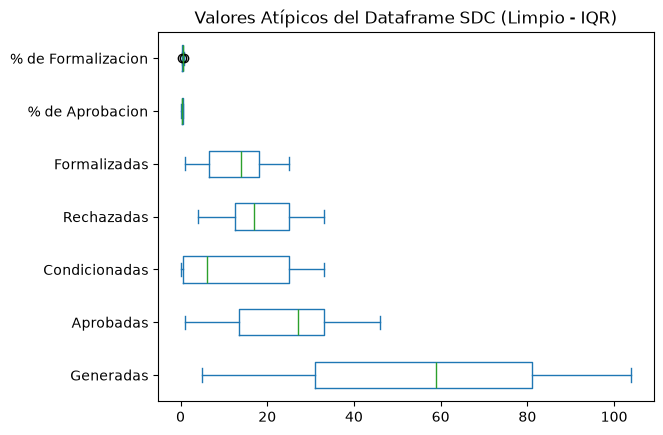

In [13]:
fig = plt.figure(figsize=(15, 8))
data4_iqr.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe SDC (Limpio - IQR)")
plt.show()

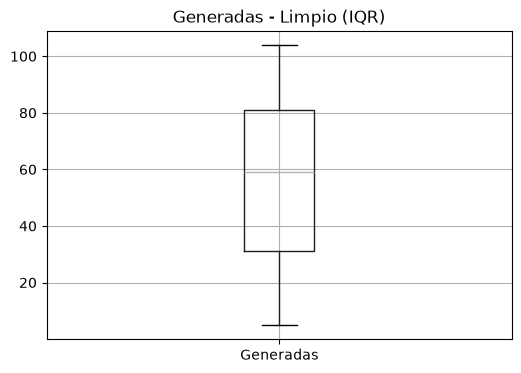

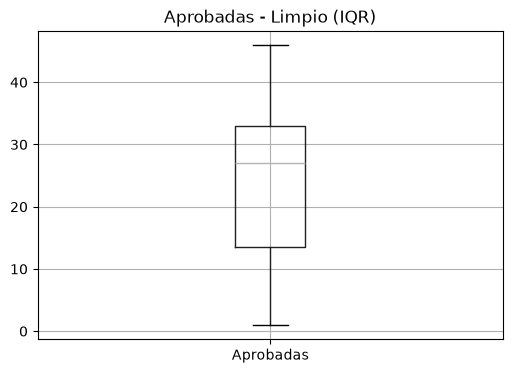

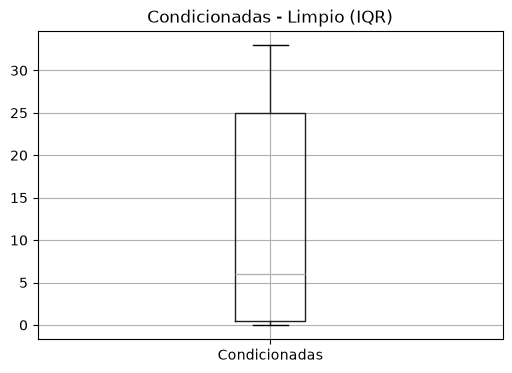

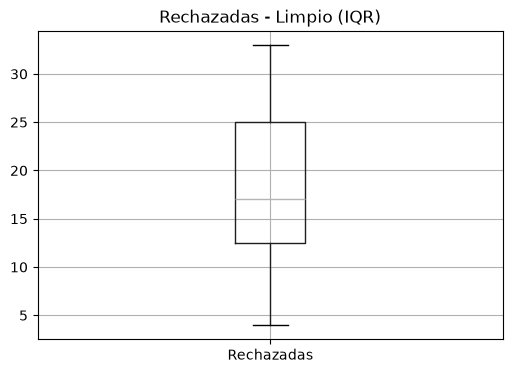

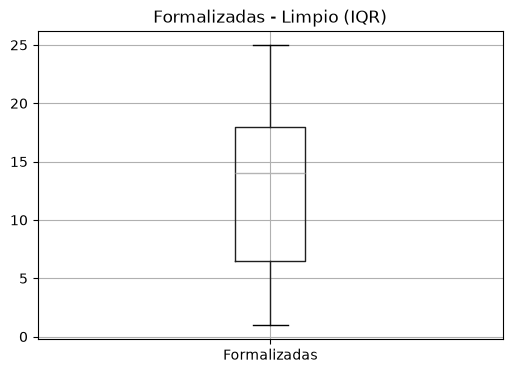

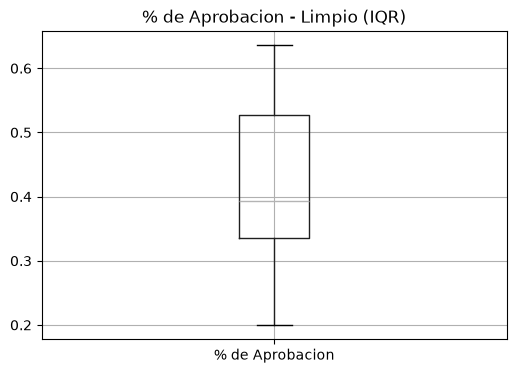

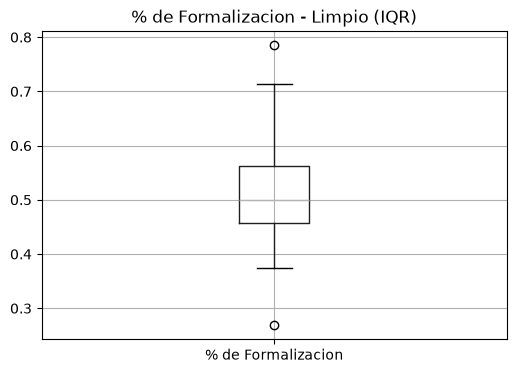

In [14]:
for columna in data4_iqr.columns:
    plt.figure(figsize=(6, 4))
    data4_iqr.boxplot(column=columna)
    plt.title(f"{columna} - Limpio (IQR)")
    plt.show()

In [15]:
data4_iqr.to_csv("SDC_limpio_iqr.csv")